<a href="https://colab.research.google.com/github/AnidaH-git/ml-products_analysis/blob/main/notebook/Task3_products_analysis_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Analysis Model



## Notebook goal

In this notebook, we explore products dataset before cleaning or modeling.

The goal is to understand:

- what the dataset contains,
- how the columns are structured,
- what types of values appear in the columns,
- where missing or inconsistent values exist,
- which problems need to be fixed during the cleaning phase.


## 1. Intro

Before training models, we need to understand the data.

A raw dataset can contain many problems:

- inconsistent column names,
- missing values,
- categorical values written inconsistently
- duplicate rows

If we train a model before checking these issues, the model may fail, or it may learn from unreliable data.

In this notebook, the goal is to inspect the dataset and identify what needs to be cleaned.

## 2. Import libraries

We start by importing the libraries needed for data exploration.

In [148]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

## 3. Load and inspect the dataset

- We load the CSV file from Github repository into a pandas DataFrame.
- Display number of columns and rowws in the dataset
- Review data types and metadata for every column

In [149]:
# load dataset from GitHub
url = "https://raw.githubusercontent.com/AnidaH-git/ml-products_analysis/main/data/products.csv"
df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())

# Print shape (number of rows and columns)
print("Dataset shape (rows, columns):", df.shape)

# Verify data types
print("\nData types:")
print(df.dtypes)

First 5 rows:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  
1      12/31/2024  
2      11/10/2024  
3   

## Standardize column names
- Before starting analyzing dataset, it is important to standardize column names

In [150]:
# Standardize column names to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.lstrip('_')

# Verify the new column names
print(df.columns)

Index(['product_id', 'product_title', 'merchant_id', 'category_label',
       'product_code', 'number_of_views', 'merchant_rating', 'listing_date'],
      dtype='object')


## Missing values evaluation
- Evaluate the number of missing values per column
- Visualize missing data using seaborn heatmap

In [151]:
# Count missing values per column
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
product_id           0
product_title      172
merchant_id          0
category_label      44
product_code        95
number_of_views     14
merchant_rating    170
listing_date        59
dtype: int64


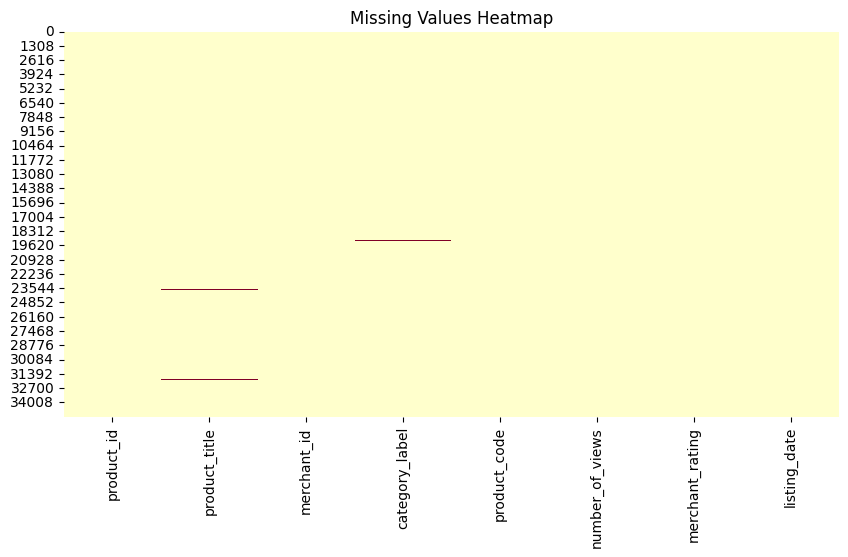

In [152]:
# Visualize missing data with seaborn heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

## Data loss after removing missing values
- Display how many rows we had before cleaning and how many we have lost after cleaning

In [153]:
# Count the number of rows before removing missing values
rows_before = len(df)

# Filter out rows that contain at least one missing value
rows_with_nan = df[df.isnull().any(axis=1)]

# Display a random sample of rows that will be remove
print(" Randomly selected rows containing missing values:\n")
print(rows_with_nan.sample(n=min(5, len(rows_with_nan)), random_state=42))

# Remove rows with any missing values
df_cleaned = df.dropna()

# Count the number of rows after removing missing values
rows_after = len(df_cleaned)

# Show removal statistics
print("\n Removal statistics:")
print(f"- Number of rows before: {rows_before}")
print(f"- Number of rows after: {rows_after}")
print(f"- Number of removed rows: {rows_before - rows_after}")

 Randomly selected rows containing missing values:

       product_id                                      product_title  \
34920       46948                                                NaN   
5908        11926                                                NaN   
8613        14740                                                NaN   
5735        11746  lg hospitality display 55lv340c lcd tv 139 7 c...   
17299       27177       aeg fss62600p integrated 13 place dishwasher   

       merchant_id category_label product_code  number_of_views  \
34920          119        Fridges   FV-2962-JM           1064.0   
5908             6            TVs   LI-2450-YG           1916.0   
8613            36           CPUs   AG-9404-LG           3301.0   
5735            99            TVs   EW-2383-EQ           2212.0   
17299            1    Dishwashers   JU-2065-EQ           1857.0   

       merchant_rating listing_date  
34920              2.1    6/10/2022  
5908               1.9    3/23/2023 

*We removed 551 rows with NaN values.*

## Duplicate rows evaluation
- It is important to evaluate duplicate rows
- If duplicate rows exist, we need to remove them

In [154]:
duplicate_rows = df.duplicated()

print("Duplicate rows:", duplicate_rows.sum())

Duplicate rows: 0


*There are no duplicate rows in dataset.*

## Remove unnecessary columns
- ID columns are not important for model training

In [155]:
df = df.drop(columns=["product_id", "merchant_id", "product_code", "number_of_views", "merchant_rating", "listing_date"])
df

,product_title,category_label
0,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones
3,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones
...,...,...
35306,smeg fab28 60cm retro style right hand hinge f...,Fridges
35307,smeg fab28 60cm retro style left hand hinge fr...,Fridges
35308,smeg fab28 60cm retro style left hand hinge fr...,Fridges
35309,candy 60cm built under larder fridge cru160nek,Fridges


*Only columns relevant for model training are left.*

# Display category values and transform into category data type
- Identify different values in the column and verify their number
- Category label column is listed as object and it should be transformed into category data type

In [156]:
# Show all unique values in the sentiment column
df['category_label'].value_counts()


,count
category_label,
Fridge Freezers,5495
Washing Machines,4036
Mobile Phones,4020
CPUs,3771
TVs,3564
Fridges,3457
Dishwashers,3418
Digital Cameras,2696
Microwaves,2338


In [157]:
# Convert column type to 'category'
df['category_label'] = df['category_label'].astype('category')
print("\Category label column converted to type:", df['category_label'].dtype)

\Category label column converted to type: category


<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_497/1279893679.py:3: SyntaxWarning: invalid escape sequence '\C'
  print("\Category label column converted to type:", df['category_label'].dtype)


# Save cleaned dataset into new csv file

In [162]:
import os

# 1. Ensure the 'data' directory exists inside your cloned repository
repo_data_path = "ml-products_analysis/data"
os.makedirs(repo_data_path, exist_ok=True)

# 2. Define the exact path inside the repository
csv_target_path = os.path.join(repo_data_path, "cleaned_products.csv")

# 3. Save the DataFrame directly to that path
df.to_csv(csv_target_path, index=False)
print(f"Successfully saved directly to: {csv_target_path}")

Successfully saved directly to: ml-products_analysis/data/cleaned_products.csv
